<a href="https://colab.research.google.com/github/sesabe10/Ciencia-de-datos/blob/main/Taller_Correlacion_Pearson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el dataset

In [3]:
# Creamos el dataset exactamente como aparece en el taller
data = {
    'edad':              [25, 34, 29, 45, 31, 22, 39, 28, 41, 33],
    'ingreso_mensual':   [1800, 3200, 2100, 4000, 2600, 1500, 3500, 2200, 3800, 2700],
    'visitas_web_mes':   [12, 5, 9, 4, 10, 14, 6, 11, 3, 8],
    'tiempo_sitio_min':  [7, 6, 8, 5, 9, 10, 7, 8, 5, 7],
    'paginas_vistas':    [14, 9, 12, 8, 15, 18, 10, 13, 7, 11],
    'clics_email':       [2, 0, 1, 0, 3, 4, 1, 2, 0, 1],
    'compras_previas':   [1, 3, 2, 4, 2, 1, 3, 2, 4, 2],
    'uso_descuento':     [1, 0, 1, 0, 1, 1, 0, 1, 0, 1],
    'satisfaccion':      [3, 4, 3, 5, 4, 2, 5, 3, 5, 4],
    'abandono_cliente':  [1, 0, 1, 0, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)
df

,edad,ingreso_mensual,visitas_web_mes,tiempo_sitio_min,paginas_vistas,clics_email,compras_previas,uso_descuento,satisfaccion,abandono_cliente
0,25,1800,12,7,14,2,1,1,3,1
1,34,3200,5,6,9,0,3,0,4,0
2,29,2100,9,8,12,1,2,1,3,1
3,45,4000,4,5,8,0,4,0,5,0
4,31,2600,10,9,15,3,2,1,4,0
5,22,1500,14,10,18,4,1,1,2,1
6,39,3500,6,7,10,1,3,0,5,0
7,28,2200,11,8,13,2,2,1,3,1
8,41,3800,3,5,7,0,4,0,5,0
9,33,2700,8,7,11,1,2,1,4,0


---
## Exploración Inicial
### Paso 1 — Responder las preguntas del taller

In [5]:
print('=' * 50)
print('EXPLORACIÓN INICIAL DEL DATASET')
print('=' * 50)

# Pregunta 1: ¿Cuántas variables tiene el dataset?
filas, columnas = df.shape
print(f'\n1. Número de variables (columnas): {columnas}')
print(f'   Número de registros (filas):     {filas}')

# Pregunta 2: ¿Cuál es la variable objetivo?
print(f'\n2. Variable objetivo: abandono_cliente')
print(f'   Valores únicos: {df["abandono_cliente"].unique()}')
print(f'   (0 = No abandonó | 1 = Sí abandonó)')

# Pregunta 3: Tipos de variables
print(f'\n3. Tipos de variables:')
print(df.dtypes)

EXPLORACIÓN INICIAL DEL DATASET

1. Número de variables (columnas): 10
   Número de registros (filas):     10

2. Variable objetivo: abandono_cliente
   Valores únicos: [1 0]
   (0 = No abandonó | 1 = Sí abandonó)

3. Tipos de variables:
edad                int64
ingreso_mensual     int64
visitas_web_mes     int64
tiempo_sitio_min    int64
paginas_vistas      int64
clics_email         int64
compras_previas     int64
uso_descuento       int64
satisfaccion        int64
abandono_cliente    int64
dtype: object


In [6]:
# Estadísticas descriptivas
print('\n📊 Estadísticas descriptivas:')
df.describe().round(2)


📊 Estadísticas descriptivas:


,edad,ingreso_mensual,visitas_web_mes,tiempo_sitio_min,paginas_vistas,clics_email,compras_previas,uso_descuento,satisfaccion,abandono_cliente
count,10.00,10.0,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,32.70,2740.0,8.20,7.20,11.70,1.40,2.40,0.60,3.80,0.40
std,7.26,859.2,3.65,1.62,3.40,1.35,1.07,0.52,1.03,0.52
min,22.00,1500.0,3.00,5.00,7.00,0.00,1.00,0.00,2.00,0.00
25%,28.25,2125.0,5.25,6.25,9.25,0.25,2.00,0.00,3.00,0.00
50%,32.00,2650.0,8.50,7.00,11.50,1.00,2.00,1.00,4.00,0.00
75%,37.75,3425.0,10.75,8.00,13.75,2.00,3.00,1.00,4.75,1.00
max,45.00,4000.0,14.00,10.00,18.00,4.00,4.00,1.00,5.00,1.00


---
## Paso 2 y 3 — Cálculo de Correlación de Pearson



In [7]:
# Calcular la matriz de correlación completa
matriz_correlacion = df.corr(method='pearson')

print('Matriz de Correlación de Pearson:')
matriz_correlacion.round(3)

Matriz de Correlación de Pearson:


,edad,ingreso_mensual,visitas_web_mes,tiempo_sitio_min,paginas_vistas,clics_email,compras_previas,uso_descuento,satisfaccion,abandono_cliente
edad,1.000,0.986,-0.938,-0.817,-0.886,-0.792,0.957,-0.836,0.955,-0.795
ingreso_mensual,0.986,1.000,-0.957,-0.821,-0.893,-0.791,0.967,-0.887,0.962,-0.841
visitas_web_mes,-0.938,-0.957,1.000,0.877,0.964,0.908,-0.958,0.874,-0.903,0.779
tiempo_sitio_min,-0.817,-0.821,0.877,1.000,0.940,0.925,-0.817,0.771,-0.771,0.558
paginas_vistas,-0.886,-0.893,0.964,0.940,1.000,0.973,-0.906,0.810,-0.841,0.645
clics_email,-0.792,-0.791,0.908,0.925,0.973,1.000,-0.812,0.733,-0.733,0.542
compras_previas,0.957,0.967,-0.958,-0.817,-0.906,-0.812,1.000,-0.881,0.881,-0.721
uso_descuento,-0.836,-0.887,0.874,0.771,0.810,0.733,-0.881,1.000,-0.792,0.667
satisfaccion,0.955,0.962,-0.903,-0.771,-0.841,-0.733,0.881,-0.792,1.000,-0.875
abandono_cliente,-0.795,-0.841,0.779,0.558,0.645,0.542,-0.721,0.667,-0.875,1.000


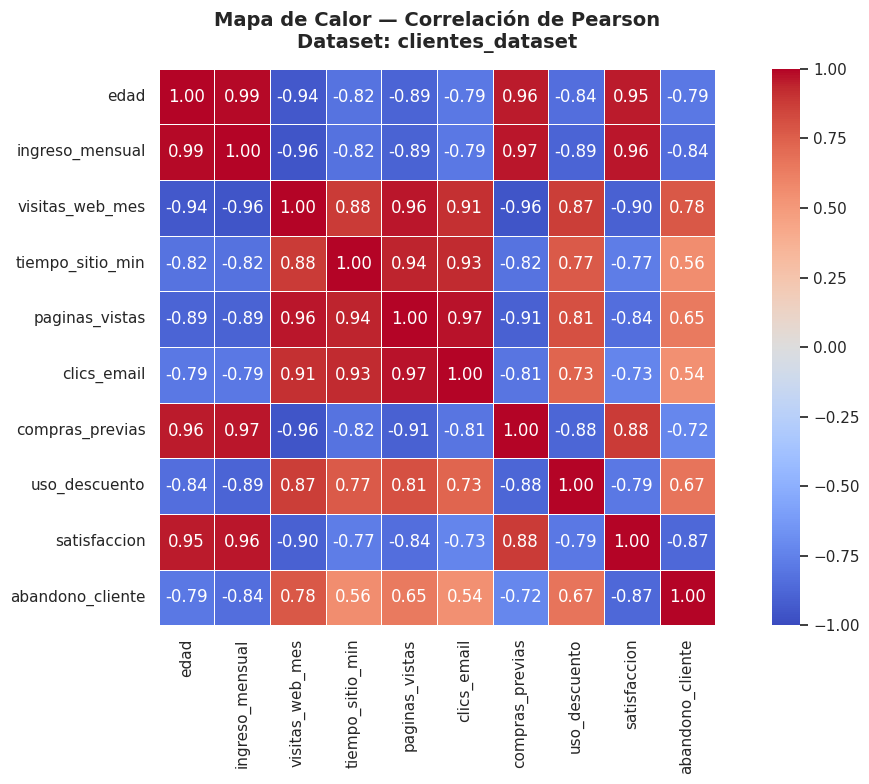

In [8]:
# Visualizar la matriz como heatmap (mapa de calor)
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,          # Mostrar los valores numéricos
    fmt='.2f',           # 2 decimales
    cmap='coolwarm',     # Rojo = positiva, Azul = negativa
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Mapa de Calor — Correlación de Pearson\nDataset: clientes_dataset',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Paso 3 — Correlación con la variable objetivo `abandono_cliente`

In [9]:
# Extraer solo la correlación con abandono_cliente
correlacion_objetivo = matriz_correlacion['abandono_cliente'].drop('abandono_cliente')

# tabla resumen
tabla_resumen = pd.DataFrame({
    'Variable': correlacion_objetivo.index,
    'Correlación': correlacion_objetivo.values.round(3),
    'Tipo de relación': ['Positiva' if v > 0 else 'Negativa' for v in correlacion_objetivo.values],
    'Fuerza': [
        'Fuerte' if abs(v) >= 0.7 else
        'Moderada' if abs(v) >= 0.4 else
        'Débil'
        for v in correlacion_objetivo.values
    ]
})

tabla_resumen = tabla_resumen.sort_values('Correlación', key=abs, ascending=False)
tabla_resumen = tabla_resumen.reset_index(drop=True)

print('📋 TABLA DEL TALLER — Correlación con abandono_cliente:')
print('=' * 65)
tabla_resumen

📋 TABLA DEL TALLER — Correlación con abandono_cliente:


,Variable,Correlación,Tipo de relación,Fuerza
0,satisfaccion,-0.875,Negativa,Fuerte
1,ingreso_mensual,-0.841,Negativa,Fuerte
2,edad,-0.795,Negativa,Fuerte
3,visitas_web_mes,0.779,Positiva,Fuerte
4,compras_previas,-0.721,Negativa,Fuerte
5,uso_descuento,0.667,Positiva,Moderada
6,paginas_vistas,0.645,Positiva,Moderada
7,tiempo_sitio_min,0.558,Positiva,Moderada
8,clics_email,0.542,Positiva,Moderada


/tmp/ipykernel_36828/3638676657.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36828/3638676657.py:21: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


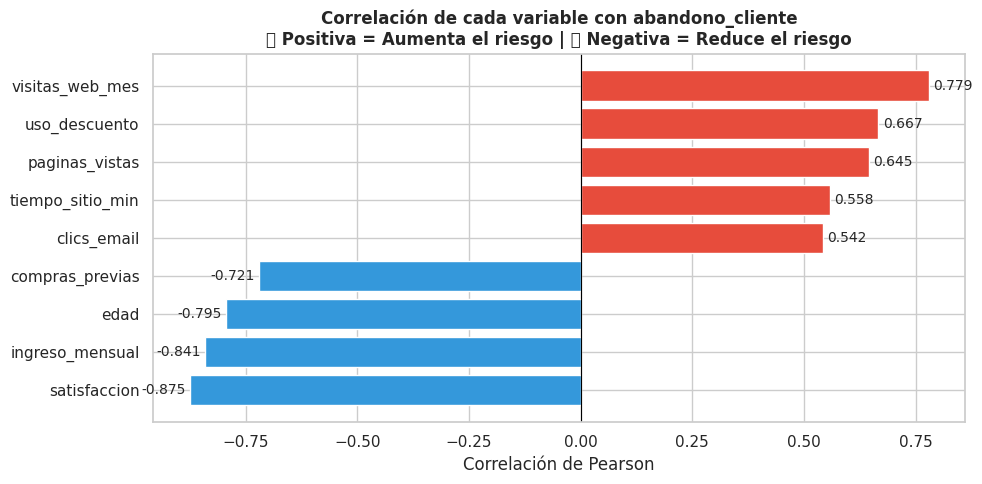

In [10]:
# Gráfico de barras de correlación con la variable objetivo
colores = ['#e74c3c' if v > 0 else '#3498db' for v in correlacion_objetivo.sort_values().values]

plt.figure(figsize=(10, 5))
bars = plt.barh(
    correlacion_objetivo.sort_values().index,
    correlacion_objetivo.sort_values().values,
    color=colores,
    edgecolor='white'
)

# Añadir etiquetas
for bar, val in zip(bars, correlacion_objetivo.sort_values().values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con abandono_cliente\n🔴 Positiva = Aumenta el riesgo | 🔵 Negativa = Reduce el riesgo',
          fontsize=12, fontweight='bold')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

---
## Paso 4 — Selección de las 3 variables más relevantes

In [12]:
# Las 3 variables con mayor correlación en valor absoluto
top3 = tabla_resumen.head(3)

print('TOP 3 variables más correlacionadas con abandono_cliente:')
print('=' * 55)
for i, row in top3.iterrows():
    print(f"  {i+1}. {row['Variable']:20s} → {row['Correlación']:+.3f} ({row['Tipo de relación']}, {row['Fuerza']})")

print(f"\n Variable con correlación MÁS ALTA: {top3.iloc[0]['Variable']} ({top3.iloc[0]['Correlación']:+.3f})")

TOP 3 variables más correlacionadas con abandono_cliente:
  1. satisfaccion         → -0.875 (Negativa, Fuerte)
  2. ingreso_mensual      → -0.841 (Negativa, Fuerte)
  3. edad                 → -0.795 (Negativa, Fuerte)

 Variable con correlación MÁS ALTA: satisfaccion (-0.875)


---
## Paso 5 — Identificación de variables redundantes

> Dos variables son **redundantes** si tienen correlación muy alta entre sí (> 0.9 o < -0.9).  
> En ese caso, incluir las dos en el modelo no aporta información nueva — es como repetir la misma variable dos veces.

In [17]:
# Variables independientes (sin la variable objetivo)
variables_independientes = df.drop(columns=['abandono_cliente'])
corr_independientes = variables_independientes.corr(method='pearson')

# Buscar pares con correlación alta (> 0.9 o < -0.9)
umbral = 0.9
pares_redundantes = []

for i in range(len(corr_independientes.columns)):
    for j in range(i + 1, len(corr_independientes.columns)):  # Evitar duplicados
        var1 = corr_independientes.columns[i]
        var2 = corr_independientes.columns[j]
        corr_val = corr_independientes.iloc[i, j]
        if abs(corr_val) > umbral:
            pares_redundantes.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlación': round(corr_val, 3),
                '¿Redundantes?': 'SÍ'
            })

if pares_redundantes:
    df_redundantes = pd.DataFrame(pares_redundantes)
    print(f'  Pares con correlación > {umbral} (posiblemente redundantes):')
    print(df_redundantes.to_string(index=False))
else:
    print(f' No se encontraron pares de variables con correlación > {umbral}')
    print('   Ninguna variable es redundante con otra en este dataset.')

  Pares con correlación > 0.9 (posiblemente redundantes):
      Variable 1      Variable 2  Correlación ¿Redundantes?
            edad ingreso_mensual        0.986            SÍ
            edad visitas_web_mes       -0.938            SÍ
            edad compras_previas        0.957            SÍ
            edad    satisfaccion        0.955            SÍ
 ingreso_mensual visitas_web_mes       -0.957            SÍ
 ingreso_mensual compras_previas        0.967            SÍ
 ingreso_mensual    satisfaccion        0.962            SÍ
 visitas_web_mes  paginas_vistas        0.964            SÍ
 visitas_web_mes     clics_email        0.908            SÍ
 visitas_web_mes compras_previas       -0.958            SÍ
 visitas_web_mes    satisfaccion       -0.903            SÍ
tiempo_sitio_min  paginas_vistas        0.940            SÍ
tiempo_sitio_min     clics_email        0.925            SÍ
  paginas_vistas     clics_email        0.973            SÍ
  paginas_vistas compras_previas       -0.

In [18]:
# Ver correlaciones entre variables independientes como tabla
# (para el análisis manual del taller)
print('Correlaciones entre variables independientes:')
print('(busca valores > 0.9 o < -0.9 para redundancia)')
corr_independientes.round(3)

Correlaciones entre variables independientes:
(busca valores > 0.9 o < -0.9 para redundancia)


,edad,ingreso_mensual,visitas_web_mes,tiempo_sitio_min,paginas_vistas,clics_email,compras_previas,uso_descuento,satisfaccion
edad,1.000,0.986,-0.938,-0.817,-0.886,-0.792,0.957,-0.836,0.955
ingreso_mensual,0.986,1.000,-0.957,-0.821,-0.893,-0.791,0.967,-0.887,0.962
visitas_web_mes,-0.938,-0.957,1.000,0.877,0.964,0.908,-0.958,0.874,-0.903
tiempo_sitio_min,-0.817,-0.821,0.877,1.000,0.940,0.925,-0.817,0.771,-0.771
paginas_vistas,-0.886,-0.893,0.964,0.940,1.000,0.973,-0.906,0.810,-0.841
clics_email,-0.792,-0.791,0.908,0.925,0.973,1.000,-0.812,0.733,-0.733
compras_previas,0.957,0.967,-0.958,-0.817,-0.906,-0.812,1.000,-0.881,0.881
uso_descuento,-0.836,-0.887,0.874,0.771,0.810,0.733,-0.881,1.000,-0.792
satisfaccion,0.955,0.962,-0.903,-0.771,-0.841,-0.733,0.881,-0.792,1.000


---
## Paso 6 — Construcción del dataset reducido

> Seleccionamos **máximo 5 variables** basándonos en:
> 1. Las de mayor correlación (en valor absoluto) con `abandono_cliente`
> 2. Eliminando las redundantes entre sí

In [19]:
# Variables seleccionadas (top 5 por correlación con la variable objetivo)
top5_variables = tabla_resumen.head(5)['Variable'].tolist()

print(' Variables seleccionadas para el dataset reducido:')
for i, var in enumerate(top5_variables, 1):
    corr = tabla_resumen[tabla_resumen['Variable'] == var]['Correlación'].values[0]
    print(f'   {i}. {var:20s} → correlación: {corr:+.3f}')

# Crear el dataset reducido (variables seleccionadas + variable objetivo)
df_reducido = df[top5_variables + ['abandono_cliente']]

print(f'\n Reducción: {df.shape[1]} variables → {df_reducido.shape[1]} variables')
print(f'   (incluyendo la variable objetivo)')
print()
df_reducido

 Variables seleccionadas para el dataset reducido:
   1. satisfaccion         → correlación: -0.875
   2. ingreso_mensual      → correlación: -0.841
   3. edad                 → correlación: -0.795
   4. visitas_web_mes      → correlación: +0.779
   5. compras_previas      → correlación: -0.721

 Reducción: 10 variables → 6 variables
   (incluyendo la variable objetivo)



,satisfaccion,ingreso_mensual,edad,visitas_web_mes,compras_previas,abandono_cliente
0,3,1800,25,12,1,1
1,4,3200,34,5,3,0
2,3,2100,29,9,2,1
3,5,4000,45,4,4,0
4,4,2600,31,10,2,0
5,2,1500,22,14,1,1
6,5,3500,39,6,3,0
7,3,2200,28,11,2,1
8,5,3800,41,3,4,0
9,4,2700,33,8,2,0


---
## PARTE 2 — Interpretación Conceptual

Respuestas a las preguntas del taller:

In [20]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PARTE 2 — Respuestas de Interpretación
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ¿Qué significa una correlación NEGATIVA en este contexto?
   → Que cuando esa variable SUBE, la probabilidad de abandono BAJA.
   Ejemplo: si satisfacción sube, el cliente es menos propenso a irse.

2. Relación entre satisfacción y abandono_cliente:
   → La correlación es NEGATIVA y fuerte.
   Clientes más satisfechos tienen MENOR probabilidad de abandonar.
   Es una de las variables más importantes del modelo.

3. ¿Por qué una variable con correlación ~0 no es útil?
   → Porque no tiene relación lineal con el abandono.
   No aporta información para predecir si el cliente se irá o no.
   Incluirla solo agrega ruido y complejidad innecesaria al modelo.

4. ¿Por qué NO incluir variables altamente correlacionadas entre sí?
   → Porque es información repetida. Si dos variables dicen lo mismo,
   incluir las dos no mejora el modelo pero sí lo hace más complejo,
   más lento y más difícil de interpretar (problema: multicolinealidad).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PARTE 2 — Respuestas de Interpretación
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ¿Qué significa una correlación NEGATIVA en este contexto?
   → Que cuando esa variable SUBE, la probabilidad de abandono BAJA.
   Ejemplo: si satisfacción sube, el cliente es menos propenso a irse.

2. Relación entre satisfacción y abandono_cliente:
   → La correlación es NEGATIVA y fuerte.
   Clientes más satisfechos tienen MENOR probabilidad de abandonar.
   Es una de las variables más importantes del modelo.

3. ¿Por qué una variable con correlación ~0 no es útil?
   → Porque no tiene relación lineal con el abandono.
   No aporta información para predecir si el cliente se irá o no.
   Incluirla solo agrega ruido y complejidad innecesaria al modelo.

4. ¿Por qué NO incluir variables altamente correlacionadas entre sí?
   → Porque es información repetida. Si dos variables dicen lo mismo,
   incluir las dos no mejora el modelo pero 

---
## 📊 Visualización final — Resumen del análisis

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


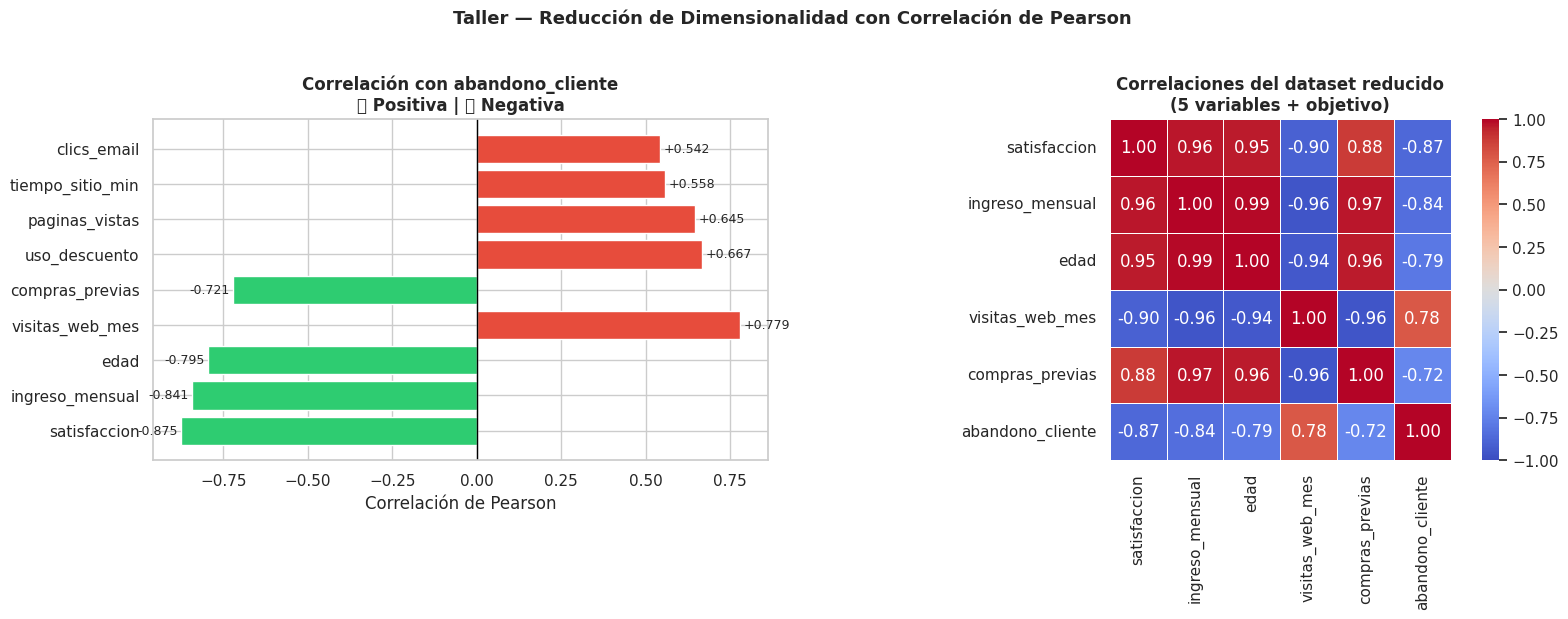


CONCLUSIÓN: Reducimos de 9 variables predictoras a 5
   Manteniendo las más informativas para predecir el abandono del cliente.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Correlaciones con abandono_cliente ---
colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in tabla_resumen['Correlación']]
axes[0].barh(tabla_resumen['Variable'], tabla_resumen['Correlación'], color=colores)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Correlación con abandono_cliente\n🔴 Positiva | 🟢 Negativa',
                   fontweight='bold')
axes[0].set_xlabel('Correlación de Pearson')
for i, (val, var) in enumerate(zip(tabla_resumen['Correlación'], tabla_resumen['Variable'])):
    axes[0].text(val + (0.01 if val >= 0 else -0.01), i, f'{val:+.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# --- Gráfico 2: Heatmap del dataset reducido ---
sns.heatmap(
    df_reducido.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=axes[1],
    square=True
)
axes[1].set_title('Correlaciones del dataset reducido\n(5 variables + objetivo)', fontweight='bold')

plt.suptitle('Taller — Reducción de Dimensionalidad con Correlación de Pearson',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nCONCLUSIÓN: Reducimos de {df.shape[1]-1} variables predictoras a {len(top5_variables)}')
print(f'   Manteniendo las más informativas para predecir el abandono del cliente.')